## Environment setup

### Configure API Key

To fine-tune RF-DETR, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy` to copy your private API key.
- In Colab, go to the left pane and click on `Secrets` (🔑).
    - Store your Roboflow API Key under the name `ROBOFLOW_API_KEY`.

In [1]:
import os
os.environ["ROBOFLOW_API_KEY"] = "DYWAoFa1ISW4I3wvHWj6" #userdata.get("ROBOFLOW_API_KEY")

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `T4 GPU`, and then click `Save`.

In [2]:
!nvidia-smi

Mon May 11 20:42:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install dependencies

Installs RF-DETR version 1.4.0 or higher, along with Supervision for benchmarking and Roboflow for pulling datasets and uploading models to the Roboflow platform.

In [3]:
!pip install -q rfdetr>=1.4.0 supervision roboflow
!pip install -q "rfdetr[train,loggers]"
!pip install -q gdown plotly supervision roboflow
!pip install -q nbformat>=4.2.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Download Dataset from Roboflow Universe


RF-DETR expects the dataset to be in COCO format. Divide your dataset into three subdirectories: `train`, `valid`, and `test`. Each subdirectory should contain its own `_annotations.coco.json` file that holds the annotations for that particular split, along with the corresponding image files. Below is an example of the directory structure:

```
dataset/
├── train/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
├── valid/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
└── test/
    ├── _annotations.coco.json
    ├── image1.jpg
    ├── image2.jpg
    └── ... (other image files)
```

[Roboflow](https://roboflow.com/annotate) allows you to create object detection datasets from scratch or convert existing datasets from formats like YOLO, and then export them in COCO JSON format for training. You can also explore [Roboflow Universe](https://universe.roboflow.com/) to find pre-labeled datasets for a range of use cases.

In [4]:
from roboflow import download_dataset

dataset = download_dataset("https://app.roboflow.com/osama-m-m-abd12-driver-gmail-com/driverbeauvoir/4", "coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DriverBeauvoir-4 in coco:: 100%|██████████| 7613/7613 [00:01<00:00, 4757.57it/s]


## Train RF-DETR on custom dataset


### Choose the right `batch_size`

Different GPUs have different amounts of VRAM (video memory), which limits how much data they can handle at once during training. To make training work well on any machine, you can adjust two settings: `batch_size` and `grad_accum_steps`. These control how many samples are processed at a time. The key is to keep their product equal to 16 — that’s our recommended total batch size. For example, on powerful GPUs like the A100, set `batch_size=16` and `grad_accum_steps=1`. On smaller GPUs like the T4, use `batch_size=4` and `grad_accum_steps=4`. We use a method called gradient accumulation, which lets the model simulate training with a larger batch size by gradually collecting updates before adjusting the weights.

In [5]:
from rfdetr import RFDETRMedium

model = RFDETRMedium()

model.train(dataset_dir=dataset.location, epochs=30, batch_size=6, grad_accum_steps=4)

[2026-05-11 20:43:54] [INFO] rf-detr - Downloading pretrained weights for rf-detr-medium.pth


rf-detr-medium.pth:   0%|          | 0.00/386M [00:00<?, ?iB/s]

[2026-05-11 20:44:01] [INFO] rf-detr - MD5 validation successful for rf-detr-medium.pth


[2026-05-11 20:44:01] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-11 20:44:01] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-05-11 20:44:03] [INFO] rf-detr - File rf-detr-medium.pth already exists with correct MD5 hash.


...

Output()

[2026-05-11 20:44:16] [INFO] rf-detr - Best EMA mAP improved to 0.0116 (epoch 0)
[2026-05-11 21:20:09] [INFO] rf-detr - Best regular mAP saved to /content/output/checkpoint_best_regular.pth (epoch 0)
[2026-05-11 21:20:13] [INFO] rf-detr - Best EMA mAP improved to 0.4862 (epoch 0)
[2026-05-11 21:56:21] [INFO] rf-detr - Best regular mAP saved to /content/output/checkpoint_best_regular.pth (epoch 1)
[2026-05-11 21:56:26] [INFO] rf-detr - Best EMA mAP improved to 0.5056 (epoch 1)
[2026-05-11 22:32:46] [INFO] rf-detr - Best regular mAP saved to /content/output/checkpoint_best_regular.pth (epoch 2)
[2026-05-11 22:32:47] [INFO] rf-detr - Best EMA mAP improved to 0.5289 (epoch 2)
[2026-05-11 23:09:38] [INFO] rf-detr - Best EMA mAP improved to 0.5445 (epoch 3)
[2026-05-11 23:46:17] [INFO] rf-detr - Best regular mAP saved to /content/output/checkpoint_best_regular.pth (epoch 4)


INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 465, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()

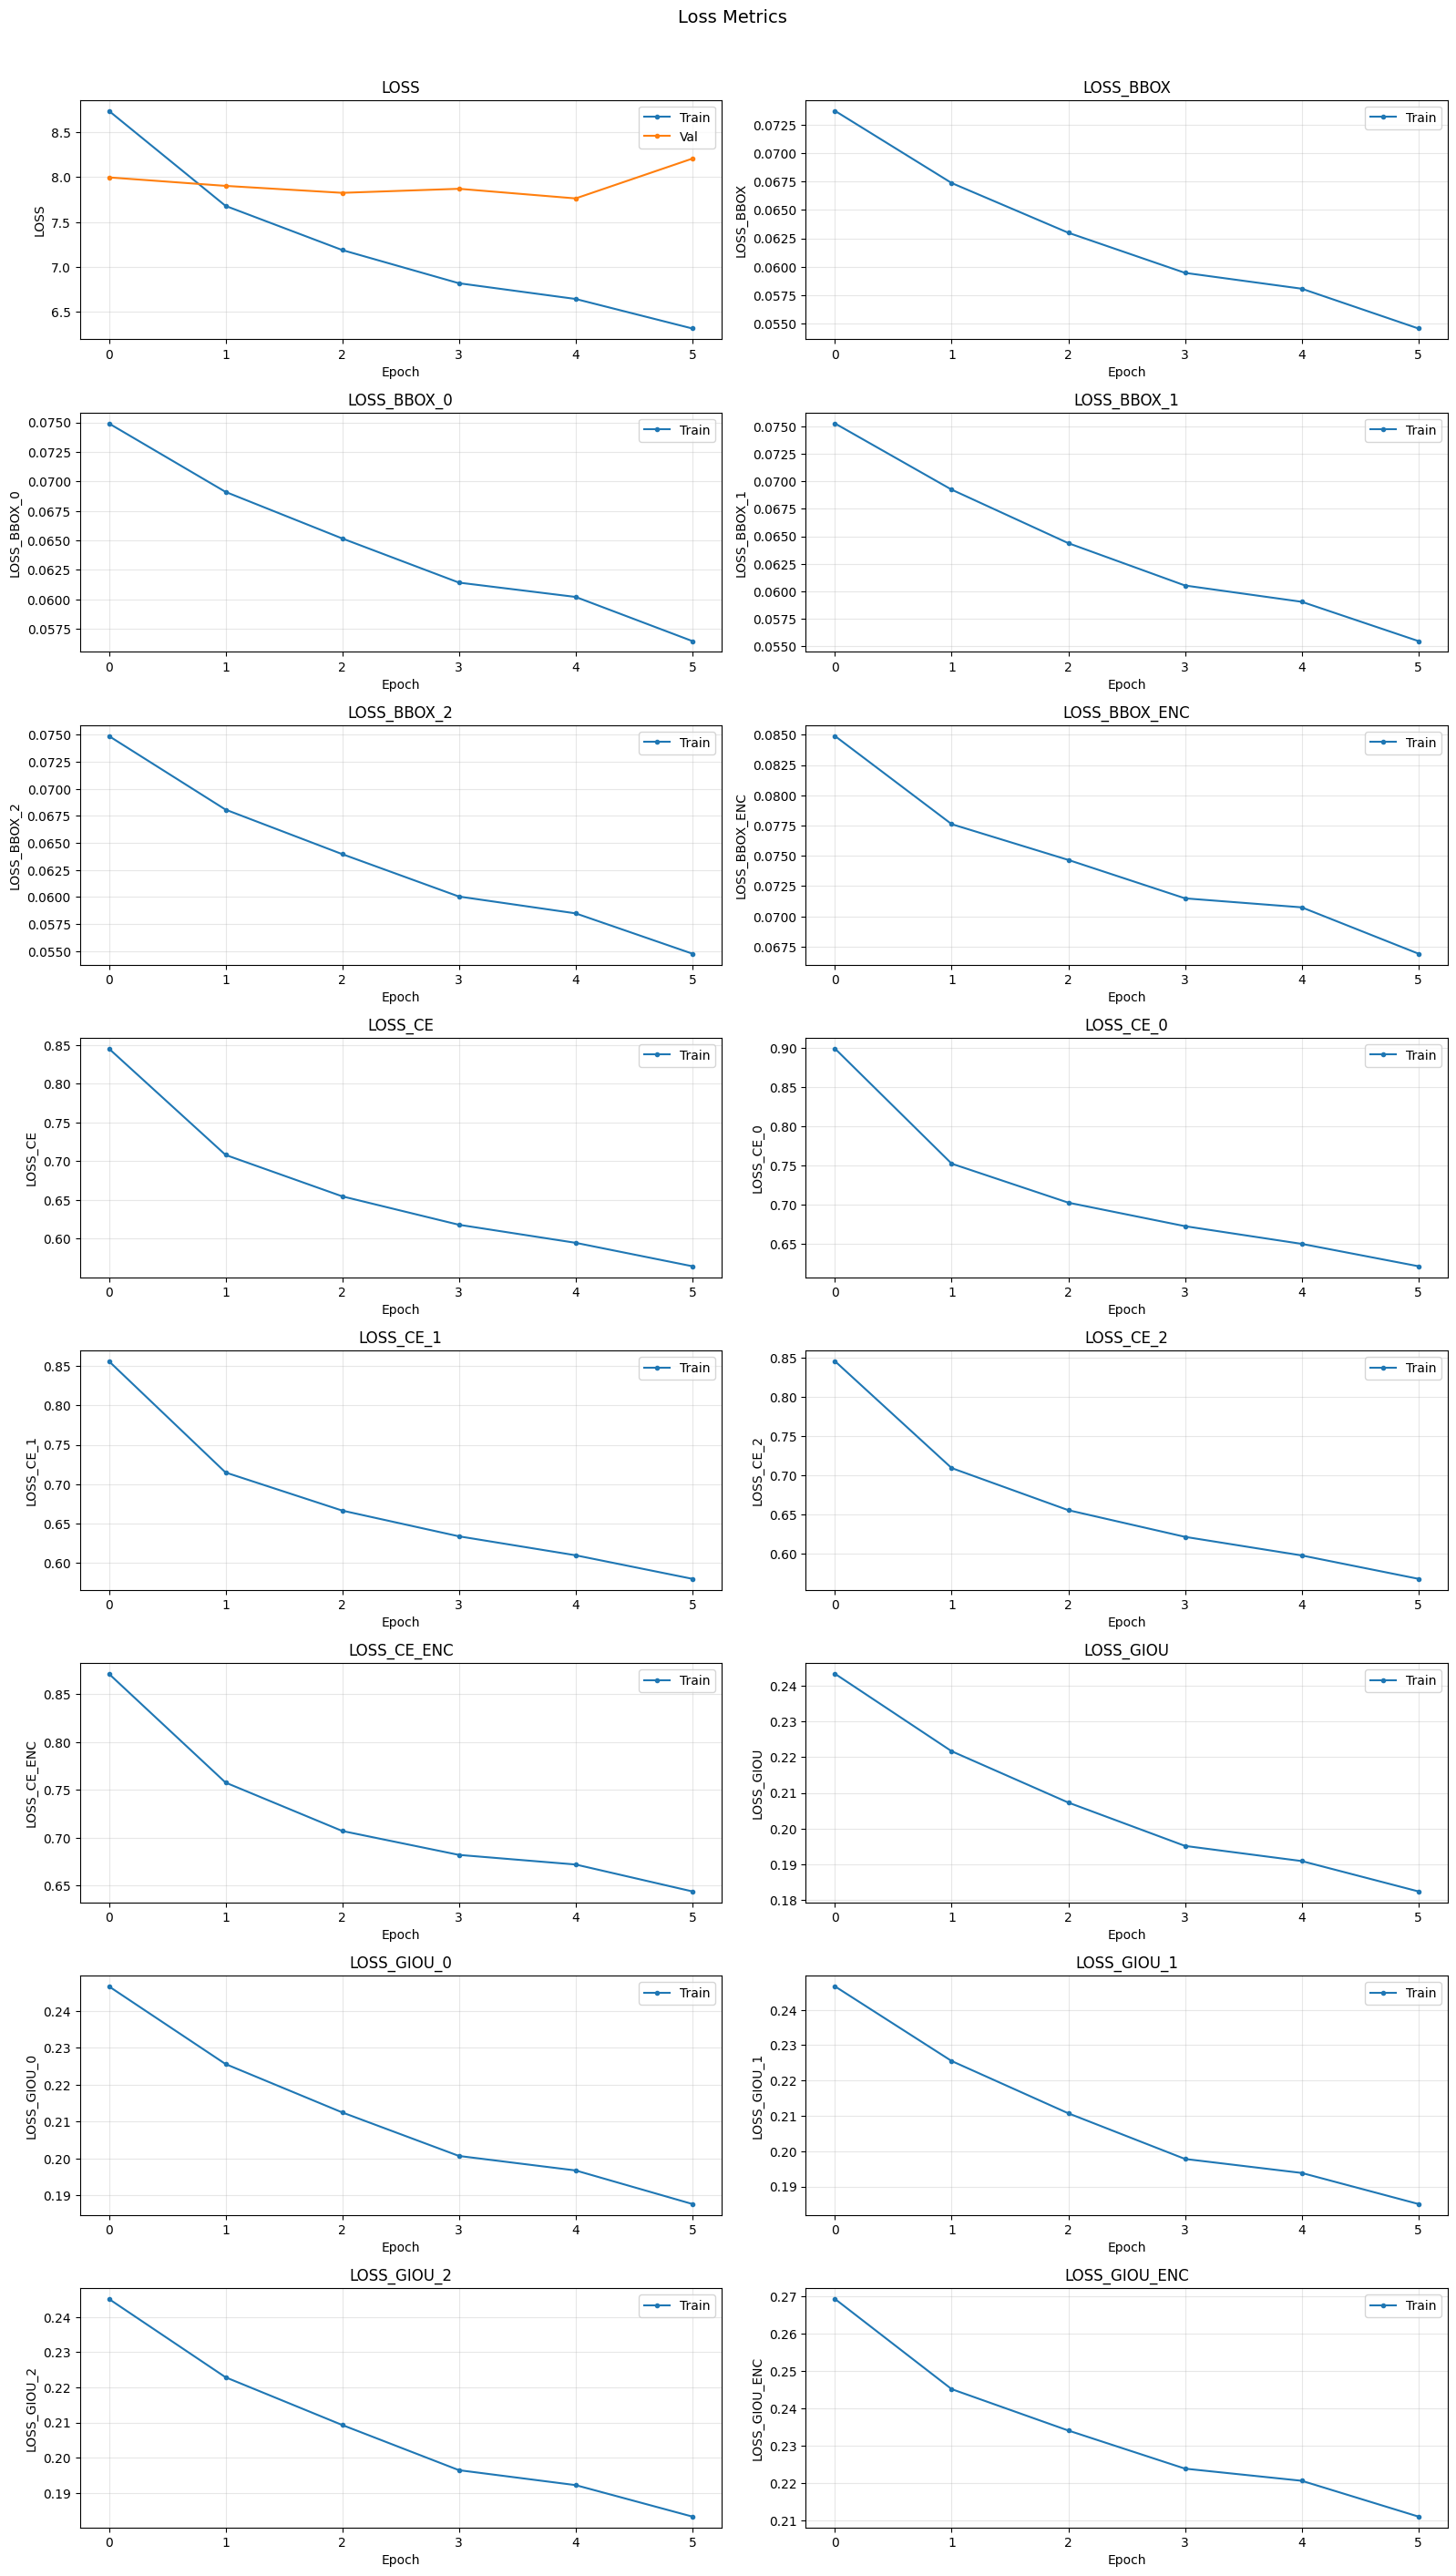

Saved chart: results/loss_metrics.png


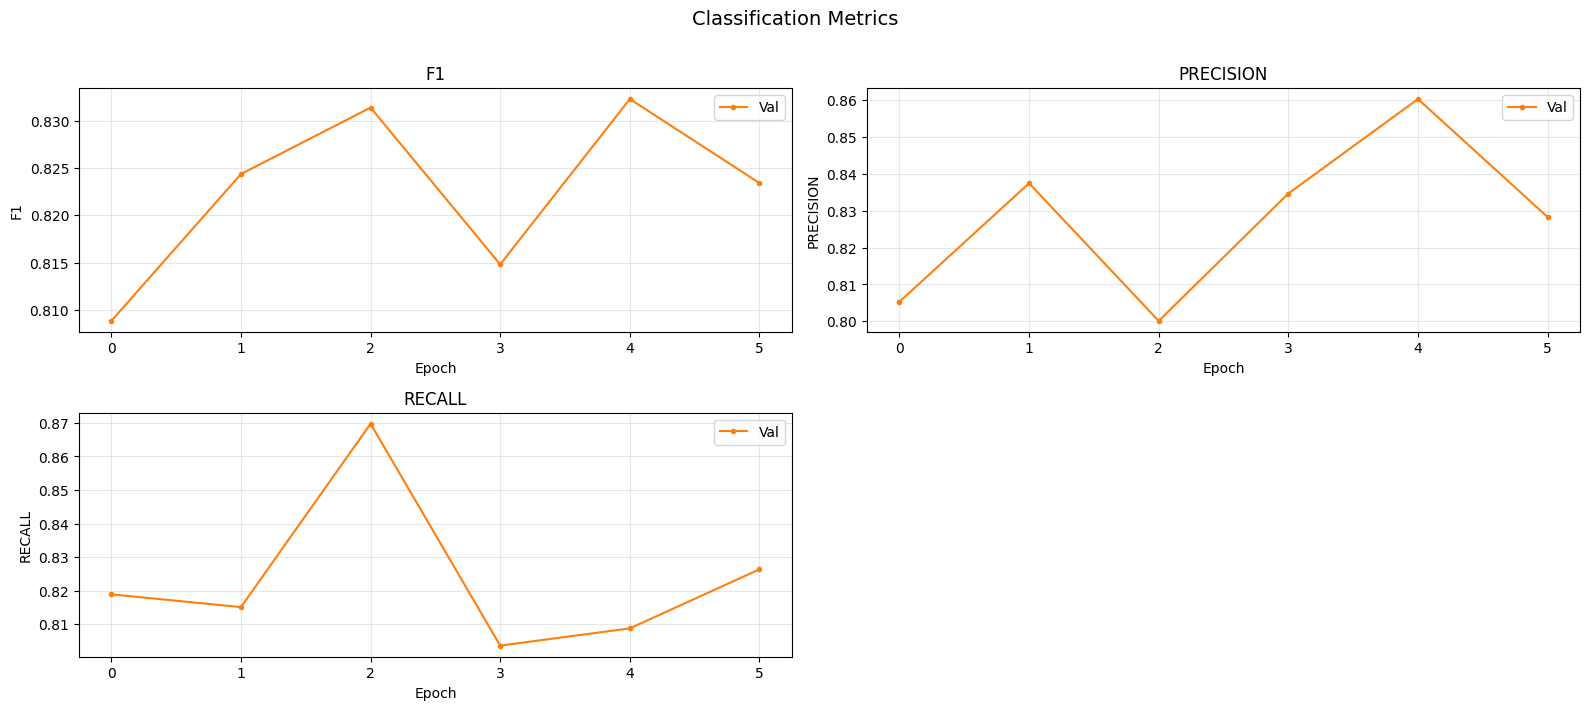

Saved chart: results/classification_metrics.png


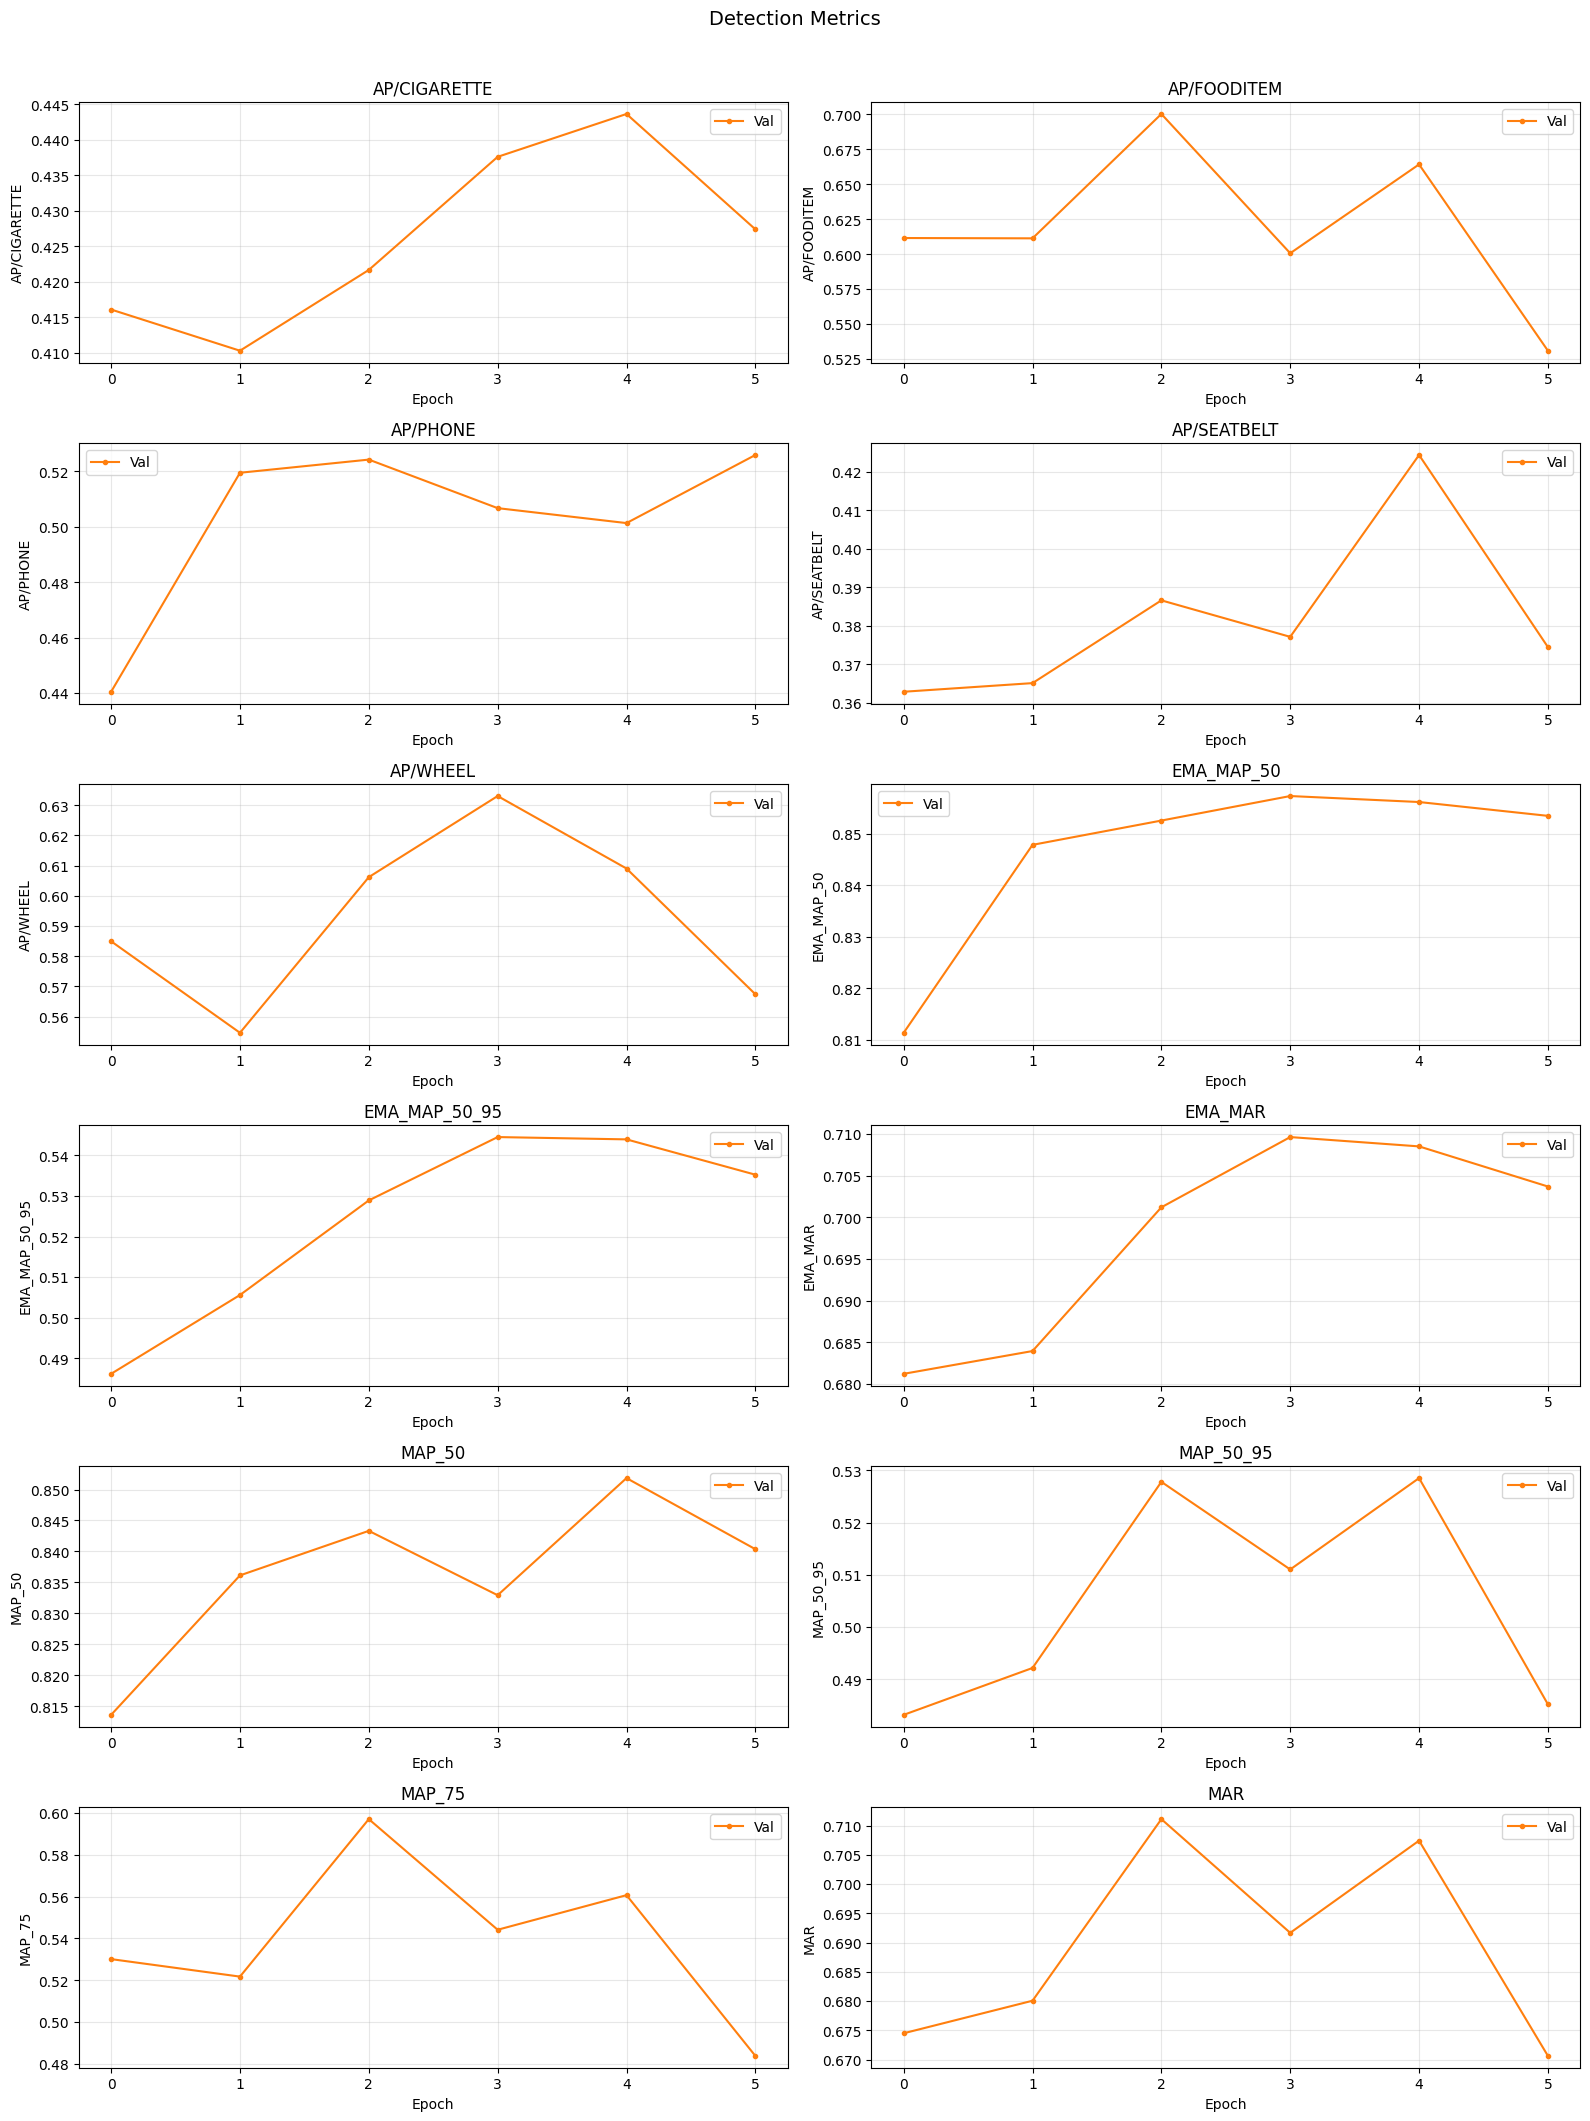

Saved chart: results/detection_metrics.png


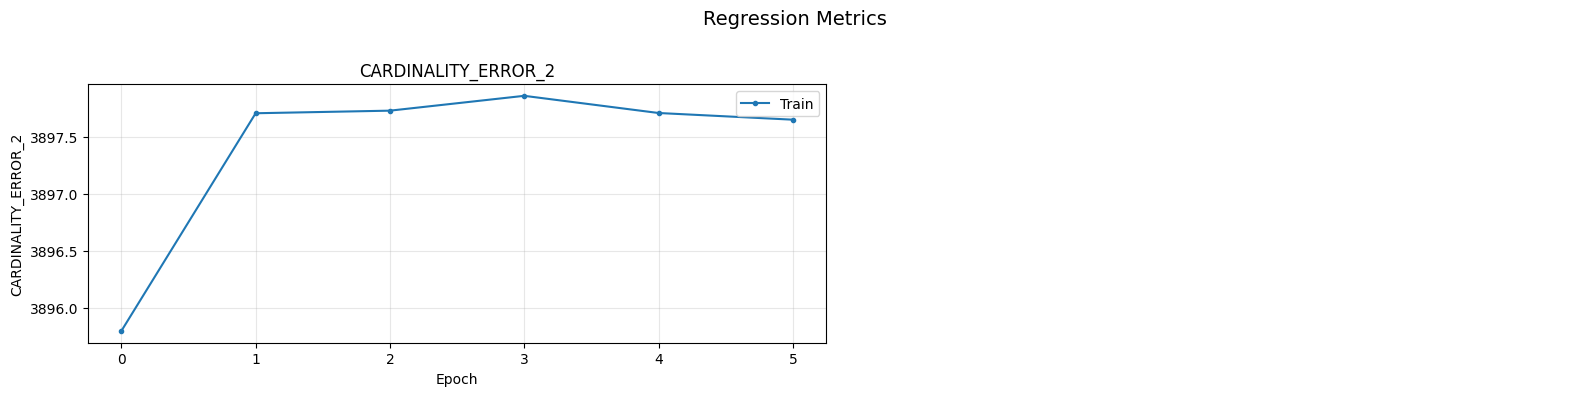

Saved chart: results/regression_metrics.png


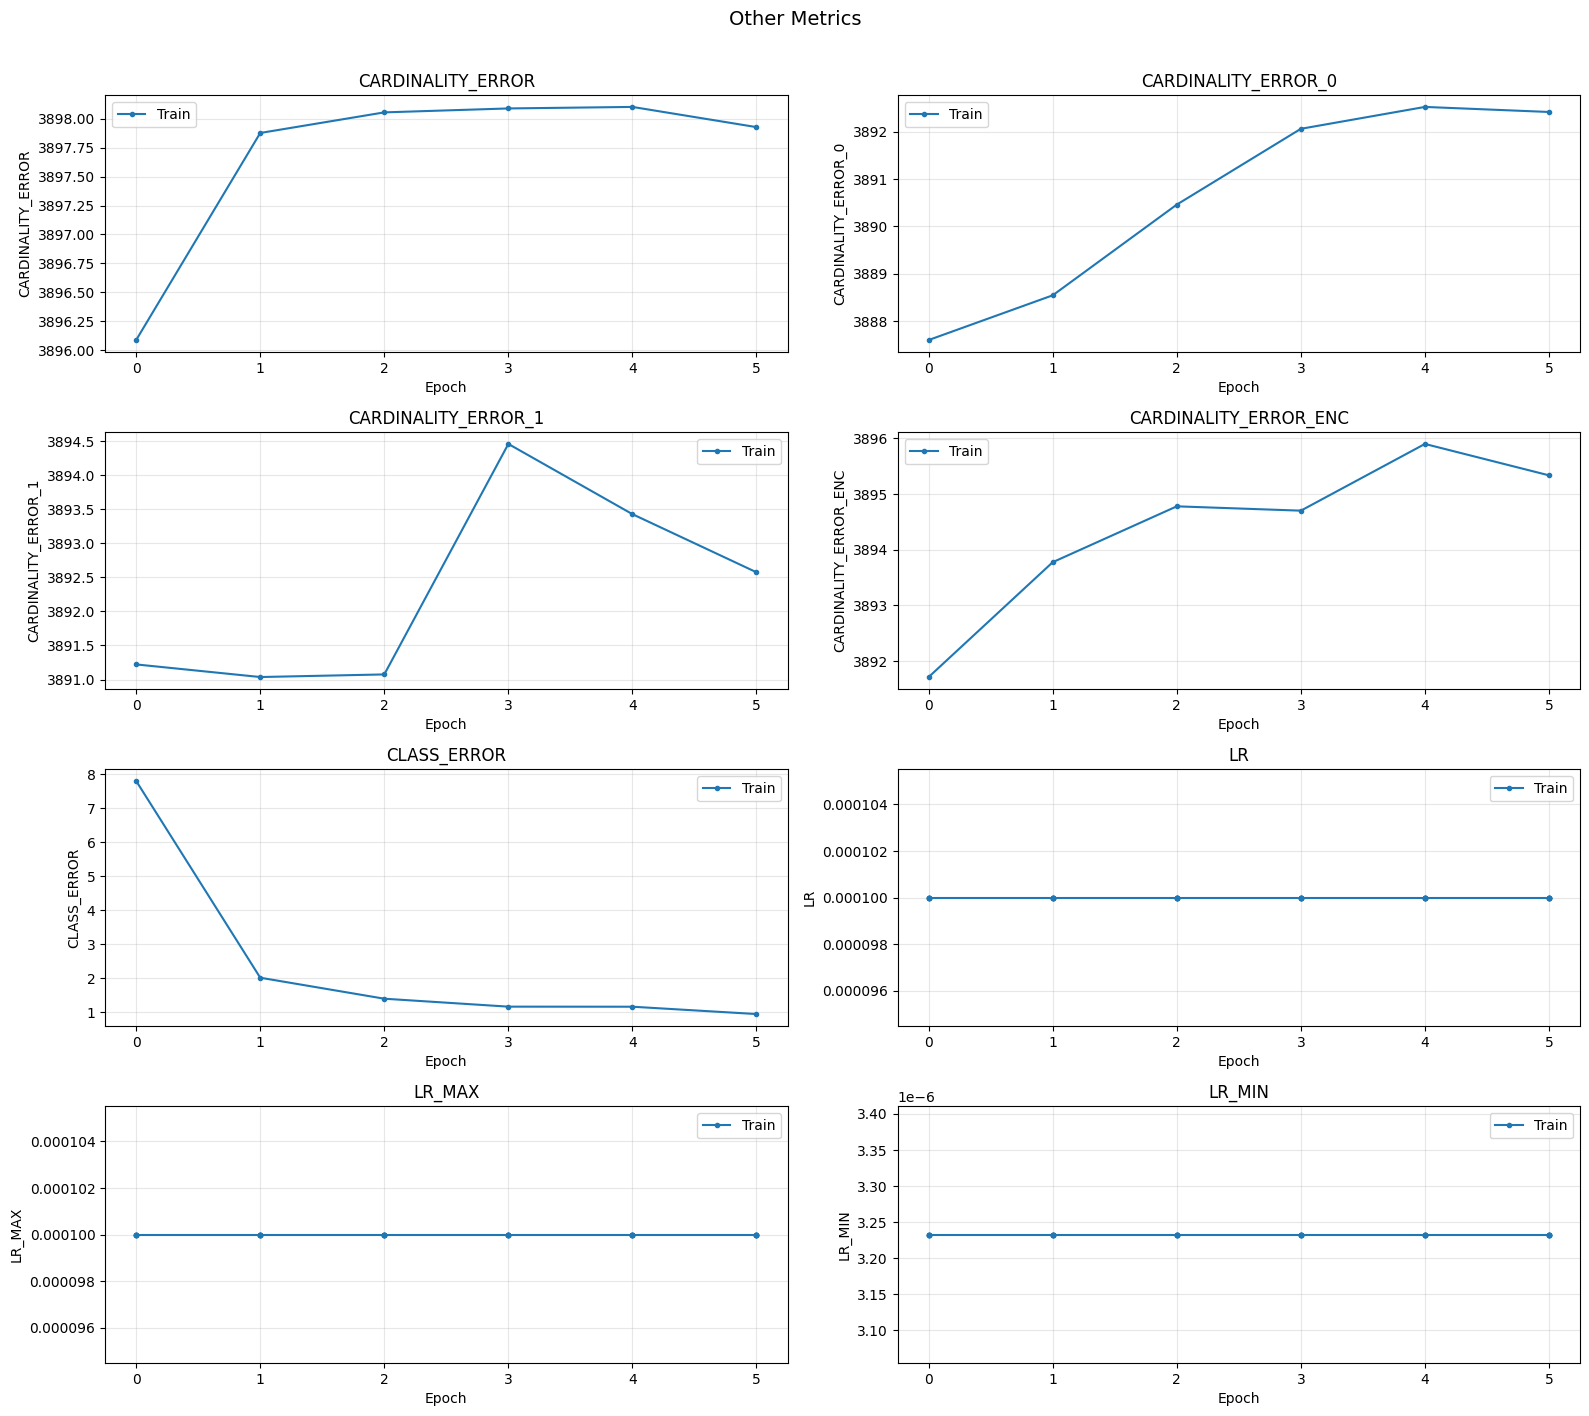

Saved chart: results/other_metrics.png

================ FINAL METRICS GRID ================

                           Train     Val  Test
Metric                                        
AP/CIGARETTE                 NaN  0.4274   NaN
AP/FOODITEM                  NaN  0.5309   NaN
AP/PHONE                     NaN  0.5259   NaN
AP/SEATBELT                  NaN  0.3745   NaN
AP/WHEEL                     NaN  0.5674   NaN
CARDINALITY_ERROR      3897.9277     NaN   NaN
CARDINALITY_ERROR_0    3892.4165     NaN   NaN
CARDINALITY_ERROR_1    3892.5745     NaN   NaN
CARDINALITY_ERROR_2    3897.6506     NaN   NaN
CARDINALITY_ERROR_ENC  3895.3328     NaN   NaN
CLASS_ERROR               0.9539     NaN   NaN
EMA_MAP_50                   NaN  0.8535   NaN
EMA_MAP_50_95                NaN  0.5353   NaN
EMA_MAR                      NaN  0.7037   NaN
F1                           NaN  0.8234   NaN
LOSS                      6.3176  8.2070   NaN
LOSS_BBOX                 0.0546     NaN   NaN
LOSS_BBOX_0  

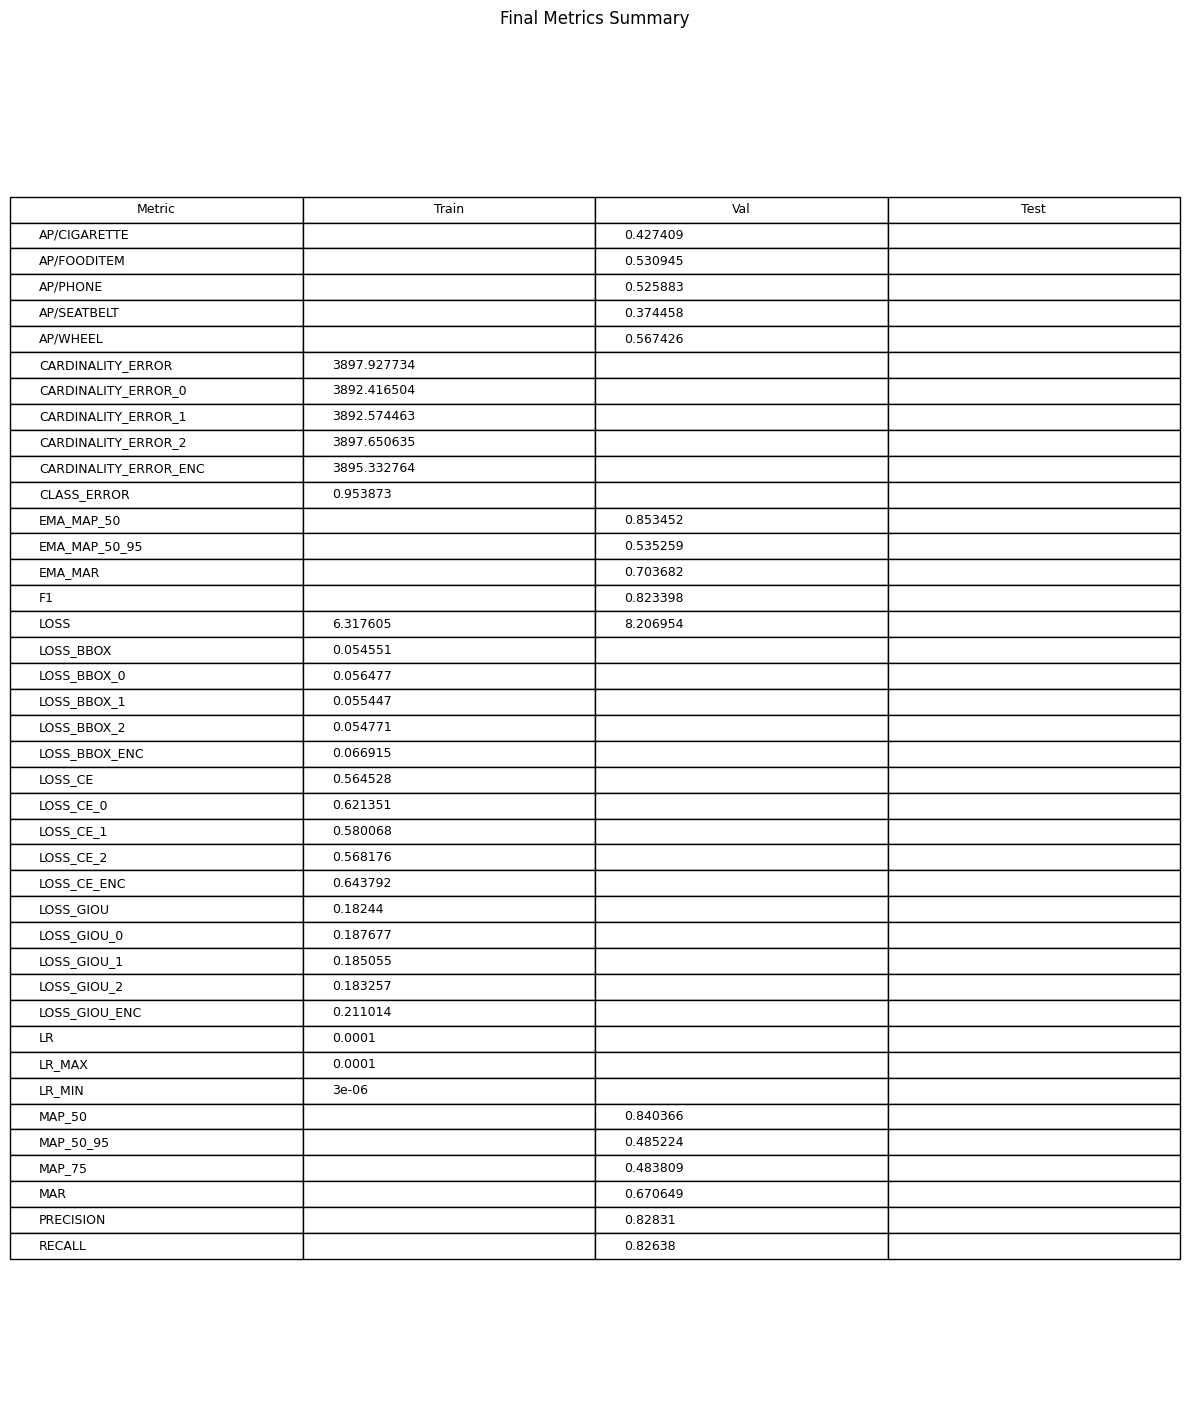

Saved: results/metrics_summary_grid.png


In [7]:
import re
from math import ceil
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# Input Data
# ======================================================
if "df" not in globals():
    df = pd.read_csv(globals().get("csv_path", "output/metrics.csv"))

x_col = "epoch" if "epoch" in df.columns else None
x_label = "Epoch" if x_col else "Index"

# ======================================================
# Helpers
# ======================================================
def norm(text: str) -> str:
    return re.sub(r"[^a-z0-9]", "", str(text).lower())

def safe_name(text: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_-]+", "_", str(text).strip().lower())

splits = list(globals().get("splits", ["train", "val", "test"]))

default_metric_groups = {
    "Loss Metrics": ["loss", "cls_loss", "box_loss", "dfl_loss"],
    "Classification Metrics": ["accuracy", "precision", "recall", "f1", "auc"],
    "Detection Metrics": ["map", "map50", "map75"],
    "Regression Metrics": ["mae", "mse", "rmse", "r2"],
}
metric_groups = globals().get("metric_groups", default_metric_groups)

# ======================================================
# Discover all available metric columns dynamically
# ======================================================
metric_split_cols = {}
for column_name in df.columns:
    if "/" not in column_name:
        continue
    split_name, metric_raw_name = column_name.split("/", 1)
    split_name = split_name.lower().strip()
    if split_name in splits:
        metric_split_cols.setdefault(metric_raw_name, {})[split_name] = column_name

# ======================================================
# Build dynamic groups with fallback rules
# ======================================================
group_norm_map = {
    group_name: {norm(metric_name) for metric_name in metric_list}
    for group_name, metric_list in metric_groups.items()
}

def guess_group(metric_raw_name: str) -> str:
    metric_norm_name = norm(metric_raw_name)

    for group_name, norm_set in group_norm_map.items():
        if metric_norm_name in norm_set:
            return group_name

    if "loss" in metric_norm_name:
        return "Loss Metrics"
    if metric_raw_name.upper().startswith("AP/") or "map" in metric_norm_name or "mar" in metric_norm_name:
        return "Detection Metrics"
    if any(key in metric_norm_name for key in ("precision", "recall", "f1", "accuracy", "auc")):
        return "Classification Metrics"
    if any(key in metric_norm_name for key in ("mae", "mse", "rmse", "r2")):
        return "Regression Metrics"
    return "Other Metrics"

available_metrics = {}
for metric_raw_name in sorted(metric_split_cols.keys(), key=lambda s: s.lower()):
    group_name = guess_group(metric_raw_name)
    available_metrics.setdefault(group_name, []).append(metric_raw_name)

group_order = [
    "Loss Metrics",
    "Classification Metrics",
    "Detection Metrics",
    "Regression Metrics",
    "Other Metrics",
]
available_metrics = {g: available_metrics[g] for g in group_order if g in available_metrics}

# ======================================================
# Output folder
# ======================================================
out_dir = Path(globals().get("out_dir", "results"))
out_dir.mkdir(parents=True, exist_ok=True)

# ======================================================
# Static charts per group using Matplotlib
# ======================================================
line_colors = {
    "train": "tab:blue",
    "val": "tab:orange",
    "test": "tab:green",
}

for current_group_name, group_metric_names in available_metrics.items():
    n_group_metrics = len(group_metric_names)
    n_cols = 2
    n_rows = ceil(n_group_metrics / n_cols)

    group_fig, group_axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(16, max(4, n_rows * 3.6)),
        squeeze=False,
    )
    flat_axes = group_axes.flatten()

    for ax_index, metric_raw_name in enumerate(group_metric_names):
        metric_ax = flat_axes[ax_index]
        has_data = False

        for split_name in splits:
            current_col_name = metric_split_cols.get(metric_raw_name, {}).get(split_name)
            if not current_col_name:
                continue

            series = df[current_col_name]
            valid_mask = series.notna()
            if not valid_mask.any():
                continue

            plot_x = df.loc[valid_mask, x_col] if x_col else df.index[valid_mask]
            plot_y = series[valid_mask]

            metric_ax.plot(
                plot_x,
                plot_y,
                marker="o",
                linewidth=1.5,
                markersize=3,
                label=split_name.capitalize(),
                color=line_colors.get(split_name),
            )
            has_data = True

        metric_ax.set_title(metric_raw_name.upper())
        metric_ax.set_xlabel(x_label)
        metric_ax.set_ylabel(metric_raw_name.upper())
        metric_ax.grid(True, alpha=0.3)

        if has_data:
            metric_ax.legend()
        else:
            metric_ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=metric_ax.transAxes,
            )

    for empty_ax in flat_axes[n_group_metrics:]:
        empty_ax.axis("off")

    group_fig.suptitle(current_group_name, fontsize=14)
    group_fig.tight_layout(rect=(0, 0, 1, 0.97))

    group_png_path = out_dir / f"{safe_name(current_group_name)}.png"
    group_fig.savefig(group_png_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(group_fig)

    print(f"Saved chart: {group_png_path}")

# ======================================================
# Final summary grid (last non-null per split/metric)
# ======================================================
summary_rows = {}
for metric_raw_name, split_map in metric_split_cols.items():
    metric_key = metric_raw_name.upper()
    for split_name, current_col_name in split_map.items():
        series = df[current_col_name].dropna()
        if not series.empty:
            summary_rows.setdefault(metric_key, {})[split_name.capitalize()] = series.iloc[-1]

summary_df = (
    pd.DataFrame.from_dict(summary_rows, orient="index")
    .reindex(columns=["Train", "Val", "Test"])
    .sort_index()
)
summary_df.index.name = "Metric"

print("\n================ FINAL METRICS GRID ================\n")
print(summary_df.round(4))

summary_csv_path = out_dir / "metrics_summary_grid.csv"
summary_df.to_csv(summary_csv_path)
print(f"\nSaved: {summary_csv_path}")

if not summary_df.empty:
    summary_table_df = summary_df.reset_index().round(6).fillna("")
    summary_fig_height = max(2.5, 0.35 * (len(summary_table_df) + 1))

    summary_fig, summary_ax = plt.subplots(figsize=(12, summary_fig_height))
    summary_ax.axis("off")
    summary_ax.set_title("Final Metrics Summary", pad=12)

    summary_table = summary_ax.table(
        cellText=summary_table_df.values.tolist(),
        colLabels=summary_table_df.columns.tolist(),
        loc="center",
        cellLoc="left",
    )
    summary_table.auto_set_font_size(False)
    summary_table.set_fontsize(9)
    summary_table.scale(1, 1.25)

    summary_png_path = out_dir / "metrics_summary_grid.png"
    summary_fig.tight_layout()
    summary_fig.savefig(summary_png_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(summary_fig)

    print(f"Saved: {summary_png_path}")


In [8]:
!ls -la output

total 783876
drwxr-xr-x 2 root root      4096 May 12 00:21 .
drwxr-xr-x 1 root root      4096 May 12 00:26 ..
-rw-r--r-- 1 root root 133762217 May 11 23:09 checkpoint_best_ema.pth
-rw-r--r-- 1 root root 133764405 May 11 23:46 checkpoint_best_regular.pth
-rw-r--r-- 1 root root     19771 May 12 00:21 events.out.tfevents.1778532249.7c63c608ff52.3253.0
-rw-r--r-- 1 root root         3 May 11 20:44 hparams.yaml
-rw------- 1 root root 535108645 May 12 00:21 last.ckpt
-rw-r--r-- 1 root root      9227 May 12 00:21 metrics.csv


### Save all data in google drive

In [28]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Define source and destination paths
source_dir = 'output'
destination_dir = '/content/drive/MyDrive/RF-DETR_Outputs'

# Create destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Copy all files from source to destination
if os.path.exists(source_dir):
    for item in os.listdir(source_dir):
        s = os.path.join(source_dir, item)
        d = os.path.join(destination_dir, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy2(s, d)
    print(f"Successfully backed up {source_dir} to {destination_dir}")
else:
    print(f"Source directory {source_dir} not found. Please ensure training or inference has produced output.")

Mounted at /content/drive
Successfully backed up output to /content/drive/MyDrive/RF-DETR_Outputs


## Deploy a Trained RF-DETR Model


Deploying to Roboflow allows you to create multi-step computer vision applications that run both in the cloud and your own hardware. Please wait a moment while Roboflow indexes your model.

In [ ]:
# model.deploy_to_roboflow(
#   workspace="roboflow-jvuqo",
#   project_id="basketball-player-detection-2",
#   version=13,
#   api_key=os.environ["ROBOFLOW_API_KEY"]
# )

## Evaluate Fine-tuned RF-DETR Model

Before benchmarking the model, we need to load the best saved checkpoint. To ensure it fits on the GPU, we first need to free up GPU memory. This involves deleting any remaining references to previously used objects, triggering Python’s garbage collector, and clearing the CUDA memory cache.

In [39]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [40]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 541.55 MB | Reserved: 1076.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 275.13 MB | Reserved: 406.00 MB


We load the best-performing model from the `checkpoint_best_total.pth` file using the `RFDETRMedium` class. This checkpoint contains the trained weights from our most successful training run. After loading, we call `optimize_for_inference()`, which prepares the model for efficient inference.

In [45]:
from rfdetr import RFDETRMedium

model = RFDETRMedium(
    pretrain_weights="/content/output/checkpoint_best_ema.pth",
    num_classes=6,
    patch_size=16
)

model.optimize_for_inference()

[2026-05-12 00:40:38] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-12 00:40:38] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


In [46]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

In [47]:
import torchvision.transforms.functional as F

_original_resize = F.resize

def safe_resize(img, size, interpolation=F.InterpolationMode.BILINEAR,
                max_size=None, antialias=False):
    return _original_resize(
        img,
        size,
        interpolation=interpolation,
        max_size=max_size,
        antialias=False
    )

F.resize = safe_resize

In [50]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision
from PIL import Image

targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

  0%|          | 0/292 [00:00<?, ?it/s]


RecursionError: maximum recursion depth exceeded

In [51]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = -1.000
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = -1.000
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000


In [52]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Overall mAP scores ──────────────────────────────────────────────────────
map50    = float(map_result.map50)
map75    = float(map_result.map75)
map50_95 = float(map_result.map50_95)

print("=" * 60)
print("              TEST SET EVALUATION RESULTS")
print("=" * 60)
print(f"  mAP@50      : {map50:.4f}   ({map50*100:.2f}%)")
print(f"  mAP@75      : {map75:.4f}   ({map75*100:.2f}%)")
print(f"  mAP@50:95   : {map50_95:.4f}   ({map50_95*100:.2f}%)")
if map_result.small_objects is not None:
    print(f"  mAP (small) : {map_result.small_objects.map50_95:.4f}   ({map_result.small_objects.map50_95*100:.2f}%)")
if map_result.medium_objects is not None:
    print(f"  mAP (medium): {map_result.medium_objects.map50_95:.4f}   ({map_result.medium_objects.map50_95*100:.2f}%)")
if map_result.large_objects is not None:
    print(f"  mAP (large) : {map_result.large_objects.map50_95:.4f}   ({map_result.large_objects.map50_95*100:.2f}%)")
print("=" * 60)

# ── Per-class AP breakdown ───────────────────────────────────────────────────
# ap_per_class: shape (num_matched_classes, num_iou_thresholds)
# matched_classes: class IDs corresponding to each row
ap_matrix      = map_result.ap_per_class         # (n_cls, n_iou)
matched_ids    = map_result.matched_classes       # (n_cls,)
iou_thresholds = map_result.iou_thresholds        # e.g. [0.5, 0.55, ..., 0.95]

rows = []
for cls_id, ap_row in zip(matched_ids, ap_matrix):
    cls_name   = ds.classes[int(cls_id)]
    valid      = ap_row[ap_row > -1]
    ap_50      = float(ap_row[0])
    ap_75      = float(ap_row[5]) if len(ap_row) > 5 else float("nan")
    ap_50_95   = float(valid.mean()) if len(valid) > 0 else 0.0
    rows.append({"Class": cls_name, "AP@50": round(ap_50, 4),
                 "AP@75": round(ap_75, 4), "AP@50:95": round(ap_50_95, 4)})

df_metrics = pd.DataFrame(rows)
df_metrics.index = df_metrics.index + 1

print("\nPer-class Average Precision:")
print(df_metrics.to_string())

# ── Bar chart ────────────────────────────────────────────────────────────────
class_names = df_metrics["Class"].tolist()
x = np.arange(len(class_names))
width = 0.28

fig, ax = plt.subplots(figsize=(max(7, len(class_names) * 2.2), 5))

b1 = ax.bar(x - width, df_metrics["AP@50"],    width, label="AP@50",    color="#2ecc71", edgecolor="white")
b2 = ax.bar(x,         df_metrics["AP@75"],    width, label="AP@75",    color="#3498db", edgecolor="white")
b3 = ax.bar(x + width, df_metrics["AP@50:95"], width, label="AP@50:95", color="#e74c3c", edgecolor="white")

for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.axhline(map50_95, color="#e74c3c", linestyle="--", linewidth=1.5, alpha=0.6,
           label=f"Overall mAP@50:95 = {map50_95:.3f}")
ax.axhline(map50,    color="#2ecc71", linestyle="--", linewidth=1.5, alpha=0.6,
           label=f"Overall mAP@50 = {map50:.3f}")

ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_xlabel("Class", fontsize=11)
ax.set_ylabel("Average Precision", fontsize=11)
ax.set_title("Test Set — Per-class AP (AP@50 / AP@75 / AP@50:95)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


              TEST SET EVALUATION RESULTS
  mAP@50      : -1.0000   (-100.00%)
  mAP@75      : -1.0000   (-100.00%)
  mAP@50:95   : -1.0000   (-100.00%)
  mAP (small) : -1.0000   (-100.00%)
  mAP (medium): -1.0000   (-100.00%)
  mAP (large) : -1.0000   (-100.00%)

Per-class Average Precision:
Empty DataFrame
Columns: []
Index: []


KeyError: 'Class'

## Run Inference with Fine-tuned RF-DETR Model

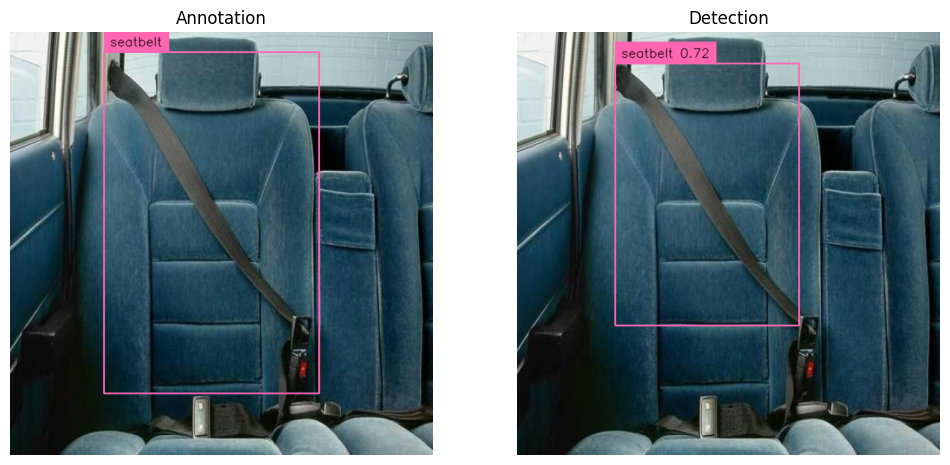

In [25]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

  VIDEO INFO
  File       : test.mp4
  Resolution : 360 × 640
  FPS        : 12.49
  Frames     : 187
  Duration   : 14.97 s

  GPU        : Tesla T4
  VRAM total : 16384 MB
  VRAM used (before inference): 269.3 MB

Running inference …  (this may take a moment)

══════════════════════════════════════════════════════════════
  FULL ANALYSIS REPORT  —  GPU: RTX 3050 Mobile 4 GB
══════════════════════════════════════════════════════════════

  TIMING
    Total wall time   : 9.56 s
    Effective FPS     : 19.56  (video FPS = 12.49)
    Real-time capable : ✓ YES
    Mean latency/frame: 42.0 ms
    Median latency    : 40.2 ms
    95th-pct latency  : 50.2 ms
    Min / Max latency : 37.5 ms / 65.2 ms

  GPU MEMORY  (RTX 3050 Mobile — 4 GB)
    VRAM before inference : 269.3 MB  (1.6%)
    VRAM peak allocated   : 299.9 MB  (1.8%)
    VRAM reserved (driver): 798.0 MB  (4.9%)
    VRAM headroom left    : 16084.1 MB  (98.2%)

  DETECTION STATISTICS
    Total frames processed: 187
    Total detection

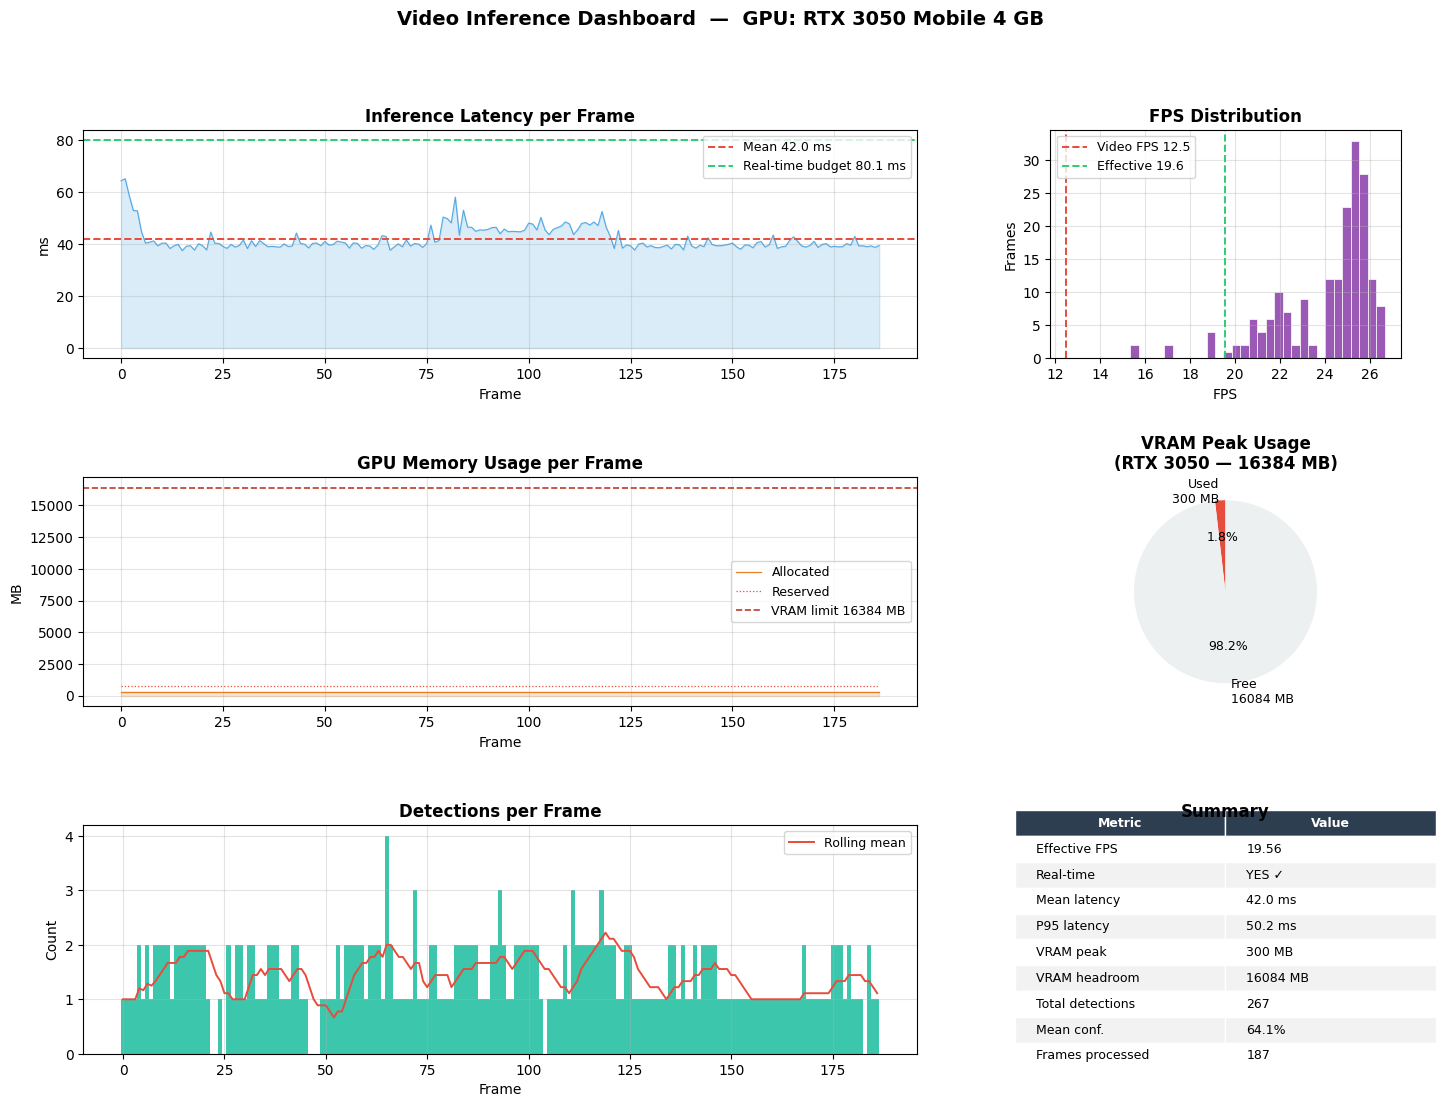


Report figure saved → output/video_inference_report.png


In [27]:

# ══════════════════════════════════════════════════════════════════════════════
#  VIDEO INFERENCE  ·  GPU PROFILING  ·  REAL-TIME ANALYSIS REPORT
#  GPU: NVIDIA RTX 3050 Mobile 4 GB
# ══════════════════════════════════════════════════════════════════════════════
import cv2, time, gc, warnings
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from collections import defaultdict
import supervision as sv

warnings.filterwarnings("ignore")

VIDEO_PATH   = "test.mp4"
OUTPUT_PATH  = "output/bus-driver-original-annotated.mp4"
THRESHOLD    = 0.35
GPU_TOTAL_MB = 16384          # T4 GPU budget

# ─── helpers ──────────────────────────────────────────────────────────────────
def gpu_mb(fn):
    return fn() / 1024**2

def reset_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

# ─── open video ───────────────────────────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Cannot open {VIDEO_PATH}"

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
vid_fps      = cap.get(cv2.CAP_PROP_FPS)
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration_s   = total_frames / vid_fps if vid_fps > 0 else 0

print("=" * 62)
print("  VIDEO INFO")
print("=" * 62)
print(f"  File       : {VIDEO_PATH}")
print(f"  Resolution : {width} × {height}")
print(f"  FPS        : {vid_fps:.2f}")
print(f"  Frames     : {total_frames}")
print(f"  Duration   : {duration_s:.2f} s")
print("=" * 62)

# ─── GPU baseline ─────────────────────────────────────────────────────────────
has_cuda = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if has_cuda else "CPU"

if has_cuda:
    torch.cuda.synchronize()
    reset_peak()
    mem_before_mb = gpu_mb(torch.cuda.memory_allocated)
    mem_reserved_before = gpu_mb(torch.cuda.memory_reserved)
else:
    mem_before_mb = mem_reserved_before = 0.0

print(f"\n  GPU        : {gpu_name}")
print(f"  VRAM total : {GPU_TOTAL_MB} MB")
print(f"  VRAM used (before inference): {mem_before_mb:.1f} MB\n")

# ─── annotator setup ──────────────────────────────────────────────────────────
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])
text_scale = sv.calculate_optimal_text_scale(resolution_wh=(width, height))
thickness  = sv.calculate_optimal_line_thickness(resolution_wh=(width, height))
box_ann    = sv.BoxAnnotator(color=color, thickness=thickness)
lbl_ann    = sv.LabelAnnotator(color=color, text_color=sv.Color.BLACK, text_scale=text_scale)

# ─── output writer ────────────────────────────────────────────────────────────
import os; os.makedirs("output", exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, vid_fps, (width, height))

# ─── per-frame buffers ────────────────────────────────────────────────────────
frame_times       = []       # inference ms per frame
mem_alloc_trace   = []       # GPU allocated MB per frame
mem_reserved_trace= []
det_counts        = []       # #detections per frame
det_confidences   = []       # mean confidence per frame
class_frame_count = defaultdict(int)   # class_name → #frames it appeared

# ─── main loop ────────────────────────────────────────────────────────────────
frame_idx = 0
print("Running inference …  (this may take a moment)")
loop_start = time.perf_counter()

while True:
    ret, bgr = cap.read()
    if not ret:
        break

    rgb   = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    pil   = Image.fromarray(rgb)

    # --- inference timing ---
    if has_cuda:
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    detections = model.predict(pil, threshold=THRESHOLD)

    if has_cuda:
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    frame_ms = (t1 - t0) * 1000
    frame_times.append(frame_ms)

    # --- GPU memory snapshot ---
    if has_cuda:
        mem_alloc_trace.append(gpu_mb(torch.cuda.memory_allocated))
        mem_reserved_trace.append(gpu_mb(torch.cuda.memory_reserved))
    else:
        mem_alloc_trace.append(0); mem_reserved_trace.append(0)

    # --- detection stats ---
    n_det = len(detections)
    det_counts.append(n_det)
    if n_det > 0:
        det_confidences.append(float(detections.confidence.mean()))
        for cid in detections.class_id:
            class_frame_count[ds.classes[int(cid)]] += 1
    else:
        det_confidences.append(0.0)

    # --- annotate & write ---
    labels = [
        f"{ds.classes[cid]} {conf:.2f}"
        for cid, conf in zip(detections.class_id, detections.confidence)
    ]
    ann = np.array(pil.copy())
    ann = np.array(box_ann.annotate(Image.fromarray(ann), detections))
    ann = np.array(lbl_ann.annotate(Image.fromarray(ann), detections, labels))
    writer.write(cv2.cvtColor(ann, cv2.COLOR_RGB2BGR))

    frame_idx += 1

loop_end = time.perf_counter()
cap.release()
writer.release()

# ─── peak GPU ────────────────────────────────────────────────────────────────
if has_cuda:
    torch.cuda.synchronize()
    mem_peak_mb     = gpu_mb(torch.cuda.max_memory_allocated)
    mem_reserved_mb = gpu_mb(torch.cuda.memory_reserved)
else:
    mem_peak_mb = mem_reserved_mb = 0.0

# ═══════════════════════════════════════════════════════════════════════════════
#  REPORT
# ═══════════════════════════════════════════════════════════════════════════════
total_wall_s  = loop_end - loop_start
eff_fps       = frame_idx / total_wall_s
mean_ms       = np.mean(frame_times)
median_ms     = np.median(frame_times)
p95_ms        = np.percentile(frame_times, 95)
min_ms        = np.min(frame_times)
max_ms        = np.max(frame_times)
realtime_ok   = eff_fps >= vid_fps

print("\n" + "═" * 62)
print("  FULL ANALYSIS REPORT  —  GPU: RTX 3050 Mobile 4 GB")
print("═" * 62)

print(f"\n  {'TIMING':}")
print(f"    Total wall time   : {total_wall_s:.2f} s")
print(f"    Effective FPS     : {eff_fps:.2f}  (video FPS = {vid_fps:.2f})")
print(f"    Real-time capable : {'✓ YES' if realtime_ok else '✗ NO  (below video FPS)'}")
print(f"    Mean latency/frame: {mean_ms:.1f} ms")
print(f"    Median latency    : {median_ms:.1f} ms")
print(f"    95th-pct latency  : {p95_ms:.1f} ms")
print(f"    Min / Max latency : {min_ms:.1f} ms / {max_ms:.1f} ms")

print(f"\n  {'GPU MEMORY  (RTX 3050 Mobile — 4 GB)'}")
print(f"    VRAM before inference : {mem_before_mb:.1f} MB  ({mem_before_mb/GPU_TOTAL_MB*100:.1f}%)")
print(f"    VRAM peak allocated   : {mem_peak_mb:.1f} MB  ({mem_peak_mb/GPU_TOTAL_MB*100:.1f}%)")
print(f"    VRAM reserved (driver): {mem_reserved_mb:.1f} MB  ({mem_reserved_mb/GPU_TOTAL_MB*100:.1f}%)")
print(f"    VRAM headroom left    : {GPU_TOTAL_MB - mem_peak_mb:.1f} MB  ({(1 - mem_peak_mb/GPU_TOTAL_MB)*100:.1f}%)")

total_dets = sum(det_counts)
mean_conf  = np.mean([c for c in det_confidences if c > 0]) if any(c > 0 for c in det_confidences) else 0
print(f"\n  {'DETECTION STATISTICS'}")
print(f"    Total frames processed: {frame_idx}")
print(f"    Total detections      : {total_dets}")
print(f"    Mean detections/frame : {np.mean(det_counts):.2f}")
print(f"    Frames with detections: {sum(1 for c in det_counts if c > 0)}  "
      f"({sum(1 for c in det_counts if c > 0)/frame_idx*100:.1f}%)")
print(f"    Mean confidence       : {mean_conf:.4f}  ({mean_conf*100:.2f}%)")
print(f"\n  Per-class detection frequency:")
for cls_name, cnt in sorted(class_frame_count.items(), key=lambda x: -x[1]):
    pct = cnt / frame_idx * 100
    print(f"    {cls_name:<20s}: {cnt:4d} frames  ({pct:.1f}%)")

print(f"\n  Output video: {OUTPUT_PATH}")
print("═" * 62)

# ═══════════════════════════════════════════════════════════════════════════════
#  DASHBOARD PLOTS
# ═══════════════════════════════════════════════════════════════════════════════
frame_nums = np.arange(len(frame_times))

fig = plt.figure(figsize=(17, 12))
fig.suptitle("Video Inference Dashboard  —  GPU: RTX 3050 Mobile 4 GB",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)

# 1) Per-frame inference time
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(frame_nums, frame_times, color="#3498db", linewidth=0.8, alpha=0.8)
ax1.axhline(mean_ms, color="#e74c3c", linestyle="--", linewidth=1.4, label=f"Mean {mean_ms:.1f} ms")
ax1.axhline(1000/vid_fps, color="#2ecc71", linestyle="--", linewidth=1.4,
            label=f"Real-time budget {1000/vid_fps:.1f} ms")
ax1.fill_between(frame_nums, frame_times, alpha=0.18, color="#3498db")
ax1.set_title("Inference Latency per Frame", fontweight="bold")
ax1.set_xlabel("Frame"); ax1.set_ylabel("ms")
ax1.legend(fontsize=9); ax1.grid(alpha=0.35)

# 2) FPS histogram
ax2 = fig.add_subplot(gs[0, 2])
instant_fps = [1000/t if t > 0 else 0 for t in frame_times]
ax2.hist(instant_fps, bins=30, color="#9b59b6", edgecolor="white", linewidth=0.5)
ax2.axvline(vid_fps, color="#e74c3c", linestyle="--", linewidth=1.4, label=f"Video FPS {vid_fps:.1f}")
ax2.axvline(eff_fps, color="#2ecc71", linestyle="--", linewidth=1.4, label=f"Effective {eff_fps:.1f}")
ax2.set_title("FPS Distribution", fontweight="bold")
ax2.set_xlabel("FPS"); ax2.set_ylabel("Frames")
ax2.legend(fontsize=9); ax2.grid(alpha=0.35)

# 3) GPU allocated memory
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(frame_nums, mem_alloc_trace, color="#e67e22", linewidth=0.9, label="Allocated")
ax3.plot(frame_nums, mem_reserved_trace, color="#e74c3c", linewidth=0.9, linestyle=":", label="Reserved")
ax3.axhline(GPU_TOTAL_MB, color="#c0392b", linestyle="--", linewidth=1.2, label=f"VRAM limit {GPU_TOTAL_MB} MB")
ax3.fill_between(frame_nums, mem_alloc_trace, alpha=0.2, color="#e67e22")
ax3.set_title("GPU Memory Usage per Frame", fontweight="bold")
ax3.set_xlabel("Frame"); ax3.set_ylabel("MB")
ax3.legend(fontsize=9); ax3.grid(alpha=0.35)

# 4) GPU memory pie
ax4 = fig.add_subplot(gs[1, 2])
used     = mem_peak_mb
headroom = max(0, GPU_TOTAL_MB - used)
wedge_cols = ["#e74c3c", "#ecf0f1"]
ax4.pie([used, headroom], labels=[f"Used\n{used:.0f} MB", f"Free\n{headroom:.0f} MB"],
        colors=wedge_cols, autopct="%1.1f%%", startangle=90,
        textprops={"fontsize": 9})
ax4.set_title(f"VRAM Peak Usage\n(RTX 3050 — {GPU_TOTAL_MB} MB)", fontweight="bold")

# 5) Detections per frame
ax5 = fig.add_subplot(gs[2, :2])
ax5.bar(frame_nums, det_counts, color="#1abc9c", width=1.0, alpha=0.85)
ax5.plot(frame_nums,
         pd.Series(det_counts).rolling(max(1, len(det_counts)//20), min_periods=1).mean(),
         color="#e74c3c", linewidth=1.4, label="Rolling mean")
ax5.set_title("Detections per Frame", fontweight="bold")
ax5.set_xlabel("Frame"); ax5.set_ylabel("Count")
ax5.legend(fontsize=9); ax5.grid(alpha=0.35)

# 6) Summary table
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis("off")
summary_data = [
    ["Effective FPS",    f"{eff_fps:.2f}"],
    ["Real-time",        "YES ✓" if realtime_ok else "NO ✗"],
    ["Mean latency",     f"{mean_ms:.1f} ms"],
    ["P95 latency",      f"{p95_ms:.1f} ms"],
    ["VRAM peak",        f"{mem_peak_mb:.0f} MB"],
    ["VRAM headroom",    f"{GPU_TOTAL_MB - mem_peak_mb:.0f} MB"],
    ["Total detections", str(total_dets)],
    ["Mean conf.",       f"{mean_conf*100:.1f}%"],
    ["Frames processed", str(frame_idx)],
]
tbl = ax6.table(cellText=summary_data,
                colLabels=["Metric", "Value"],
                loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.55)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2c3e50"); cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#f2f2f2")
    cell.set_edgecolor("white")
ax6.set_title("Summary", fontweight="bold", pad=6)

plt.savefig("output/video_inference_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nReport figure saved → output/video_inference_report.png")
